# 00 — Data exploration (Tasks 1 & 2)

Exploratory analysis before modelling:

- Dataset sizes, class balance, and label mapping
- Handcrafted feature shapes and distributions (color / HOG-PCA / additional)
- Sample training images per class
- Sanity checks: CSV alignment, feature coverage, image paths and dimensions

Run this notebook first. Shared loaders live in `src/utils.py`.

In [9]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

from utils import REPO_ROOT as UTILS_ROOT, load_task, load_images

assert REPO_ROOT == UTILS_ROOT, f"CWD mismatch: {REPO_ROOT} vs {UTILS_ROOT}"

FIG_DIR = REPO_ROOT / "outputs" / "figures" / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

SEED = 42
rng = np.random.default_rng(SEED)

## Load both tasks

In [10]:
task1 = load_task(1)
task2 = load_task(2)

for name, bundle in [("Task 1", task1), ("Task 2", task2)]:
    print(f"=== {name} ===")
    print(f"  data dir:     {bundle['task_dir']}")
    print(f"  train images: {len(bundle['y_train']):,}")
    print(f"  test images:  {len(bundle['test_ids']):,}")
    print(f"  feature dim:  {bundle['X_handcrafted_train'].shape[1]} ({len(bundle['feature_names'])} names)")
    print(f"  classes:      {len(bundle['class_mapping'])}")
    print()

=== Task 1 ===
  data dir:     /Users/skandaramanan/Documents/ML/MLAssignment2/task1_data
  train images: 3,750
  test images:  1,250
  feature dim:  219 (219 names)
  classes:      10

=== Task 2 ===
  data dir:     /Users/skandaramanan/Documents/ML/MLAssignment2/task2_data
  train images: 417
  test images:  180
  feature dim:  219 (219 names)
  classes:      10



## Sanity checks — CSV / feature alignment

`load_task` already asserts that the three feature CSVs share identical `image_id` order and that every train/test id has a feature row. Below we add image-path checks and basic feature quality checks.

In [11]:
def feature_group_slices(feature_names: list[str]) -> dict[str, slice]:
    """Return index slices for color (96), hog_pca (100), additional (23)."""
    n_color = sum(1 for n in feature_names if n.startswith("color_"))
    n_hog = sum(1 for n in feature_names if n.startswith("hog_"))
    n_addl = len(feature_names) - n_color - n_hog
    assert n_color == 96 and n_hog == 100 and n_addl == 23, (
        f"unexpected split: color={n_color}, hog={n_hog}, addl={n_addl}"
    )
    return {
        "color": slice(0, n_color),
        "hog_pca": slice(n_color, n_color + n_hog),
        "additional": slice(n_color + n_hog, len(feature_names)),
    }


def sanity_report(bundle, task_label: str) -> dict:
    """Run alignment and data-quality checks; raise on hard failures."""
    base = bundle["task_dir"]
    train_meta = bundle["train_meta"]
    test_meta = bundle["test_meta"]
    X_tr = bundle["X_handcrafted_train"]
    X_te = bundle["X_handcrafted_test"]

    # --- feature CSV row counts = train + test ---
    for fname in ("color_histogram.csv", "hog_pca.csv", "additional_features.csv"):
        n_rows = len(pd.read_csv(base / fname))
        expected = len(train_meta) + len(test_meta)
        assert n_rows == expected, f"{fname}: {n_rows} rows != {expected}"

    # --- no NaN / inf ---
    assert np.isfinite(X_tr).all(), "NaN/inf in train features"
    assert np.isfinite(X_te).all(), "NaN/inf in test features"

    # --- image paths ---
    missing = []
    sizes = []
    for split_name, meta in [("train", train_meta), ("test", test_meta)]:
        for rel in meta["image_path"]:
            p = base / rel
            if not p.is_file():
                missing.append(str(p))
            else:
                with Image.open(p) as im:
                    sizes.append(im.size)

    assert not missing, f"{len(missing)} missing images (first: {missing[0]})"
    unique_sizes = set(sizes)
    print(f"{task_label}: all {len(sizes):,} images found; sizes {unique_sizes}")

    # --- test split has no labels (no leakage via test metadata) ---
    label_cols = {"class_id", "class_name"}
    assert not label_cols.intersection(test_meta.columns), (
        f"test_metadata must not contain labels; found {label_cols & set(test_meta.columns)}"
    )
    assert list(test_meta.columns) == ["image_id", "image_path"], (
        f"unexpected test_metadata columns: {list(test_meta.columns)}"
    )

    # --- label consistency ---
    id_name = dict(zip(bundle["class_mapping"]["class_id"], bundle["class_mapping"]["class_name"]))
    meta_mismatch = train_meta[train_meta["class_name"] != train_meta["class_id"].map(id_name)]
    assert meta_mismatch.empty, "class_id / class_name mismatch in train_metadata"

    return {
        "task": task_label,
        "n_train": len(train_meta),
        "n_test": len(test_meta),
        "feature_dim": X_tr.shape[1],
        "image_size": unique_sizes.pop() if len(unique_sizes) == 1 else unique_sizes,
        "feature_min": float(X_tr.min()),
        "feature_max": float(X_tr.max()),
    }


reports = [sanity_report(task1, "Task 1"), sanity_report(task2, "Task 2")]
pd.DataFrame(reports)

Task 1: all 5,000 images found; sizes {(64, 64)}
Task 2: all 597 images found; sizes {(128, 128)}


,task,n_train,n_test,feature_dim,image_size,feature_min,feature_max
0,Task 1,3750,1250,219,"(64, 64)",-1.372977,28785.488281
1,Task 2,417,180,219,"(128, 128)",-3.432316,10558.184570


## Class balance

Task 1 — perfectly balanced coarse classes (CIFAR-10–style categories):


,class_id,class_name,n_train,pct
0,0,bird,375,10.0
1,1,butterfly,375,10.0
2,2,cat,375,10.0
3,3,deer,375,10.0
4,4,dog,375,10.0
5,5,elephant,375,10.0
6,6,frog,375,10.0
7,7,horse,375,10.0
8,8,sheep,375,10.0
9,9,spider,375,10.0


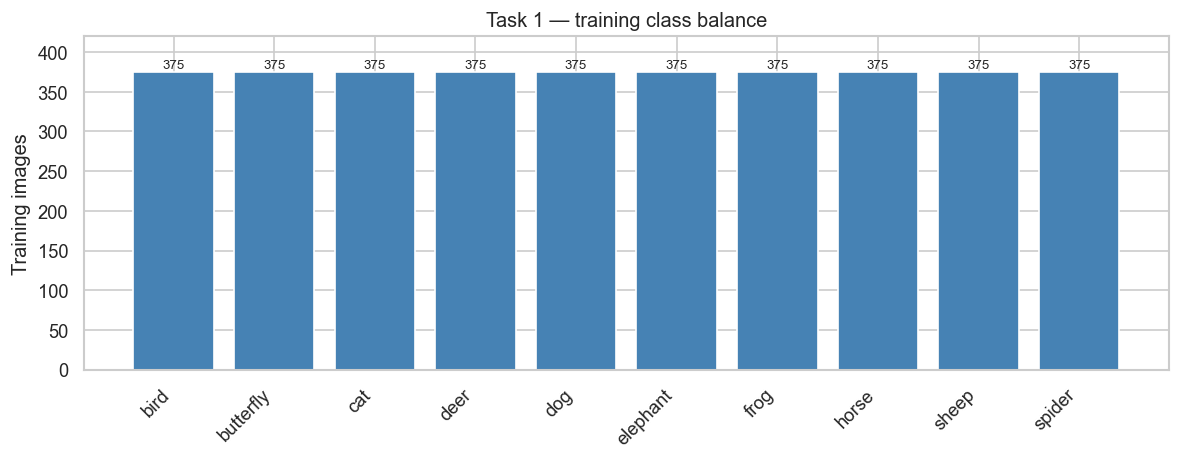

Saved /Users/skandaramanan/Documents/ML/MLAssignment2/outputs/figures/eda/task1_class_balance.png

Task 2 — fine-grained birds (small dataset, slight imbalance):


,class_id,class_name,n_train,pct
0,0,American_Goldfinch,42,10.1
1,1,Blue_Jay,42,10.1
2,2,Cardinal,39,9.4
3,3,Herring_Gull,42,10.1
4,4,House_Sparrow,42,10.1
5,5,Red_winged_Blackbird,42,10.1
6,6,Ring_billed_Gull,42,10.1
7,7,Song_Sparrow,42,10.1
8,8,Wilson_Warbler,42,10.1
9,9,Yellow_Warbler,42,10.1


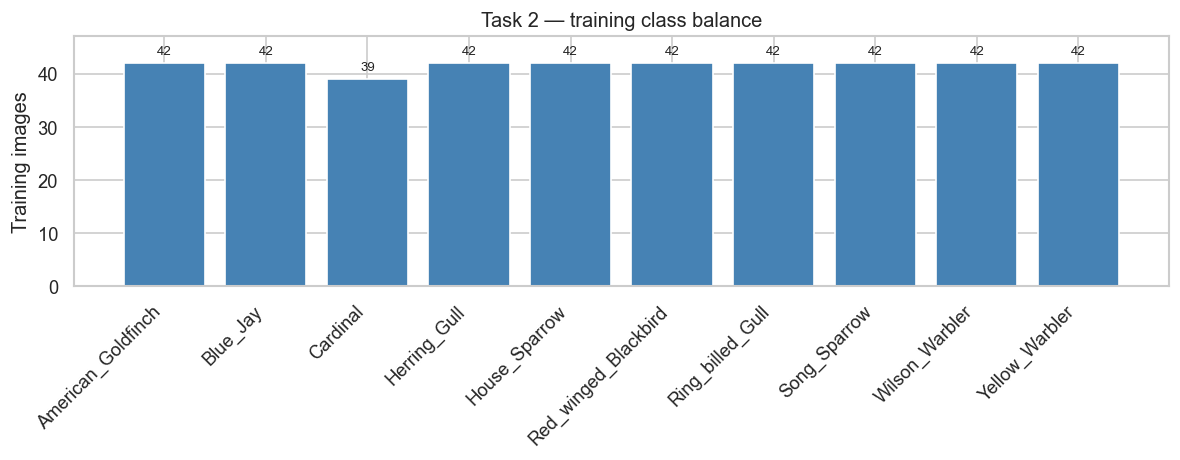

Saved /Users/skandaramanan/Documents/ML/MLAssignment2/outputs/figures/eda/task2_class_balance.png


In [12]:
def class_counts_table(bundle) -> pd.DataFrame:
    meta = bundle["train_meta"]
    counts = meta.groupby(["class_id", "class_name"]).size().reset_index(name="n_train")
    counts["pct"] = (100 * counts["n_train"] / counts["n_train"].sum()).round(1)
    return counts.sort_values("class_id")


def plot_class_balance(bundle, title: str, out_name: str):
    counts = class_counts_table(bundle)
    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(counts))
    bars = ax.bar(x, counts["n_train"], color="steelblue", edgecolor="white")
    ax.set_title(title)
    ax.set_ylabel("Training images")
    ax.set_xticks(x)
    ax.set_xticklabels(counts["class_name"], rotation=45, ha="right")
    for b, n in zip(bars, counts["n_train"]):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1, str(n), ha="center", va="bottom", fontsize=8)
    ax.set_ylim(0, counts["n_train"].max() * 1.12)
    fig.tight_layout()
    path = FIG_DIR / out_name
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved {path}")
    return counts


print("Task 1 — perfectly balanced coarse classes (CIFAR-10–style categories):")
display(class_counts_table(task1))
t1_counts = plot_class_balance(task1, "Task 1 — training class balance", "task1_class_balance.png")

print("\nTask 2 — fine-grained birds (small dataset, slight imbalance):")
display(class_counts_table(task2))
t2_counts = plot_class_balance(task2, "Task 2 — training class balance", "task2_class_balance.png")

## Handcrafted feature distributions

Provided features: **96** colour histogram bins + **100** HOG-PCA components + **23** additional descriptors = **219** dimensions per image.

**Scale warning:** the 23 additional descriptors span a much larger numeric range (max ≈ 10³–10⁴) than colour or HOG-PCA (roughly [−3, 3]). They contribute ~99.99% of each sample’s L2 norm, so the per-class L2 bar chart below reflects magnitude more than semantic structure. Every sklearn pipeline must include `StandardScaler` (already planned) before linear/kernel models.

In [13]:
def feature_summary_by_group(bundle) -> pd.DataFrame:
    slices = feature_group_slices(bundle["feature_names"])
    X = bundle["X_handcrafted_train"]
    rows = []
    for group, sl in slices.items():
        block = X[:, sl]
        rows.append({
            "group": group,
            "dims": block.shape[1],
            "mean": block.mean(),
            "std": block.std(),
            "min": block.min(),
            "max": block.max(),
        })
    return pd.DataFrame(rows)


print("Task 1 feature group summary (train):")
display(feature_summary_by_group(task1))
print("Task 2 feature group summary (train):")
display(feature_summary_by_group(task2))

# Confirm additional block dominates vector magnitude (justifies StandardScaler)
def l2_norm_fraction_by_group(bundle) -> pd.DataFrame:
    slices = feature_group_slices(bundle["feature_names"])
    X = bundle["X_handcrafted_train"]
    total = np.linalg.norm(X, axis=1)
    rows = []
    for group, sl in slices.items():
        frac = np.linalg.norm(X[:, sl], axis=1) / np.maximum(total, 1e-12)
        rows.append({"group": group, "mean_L2_fraction": frac.mean(), "max_L2_fraction": frac.max()})
    return pd.DataFrame(rows)

print("\nShare of per-sample L2 norm by feature group (train):")
display(l2_norm_fraction_by_group(task1))
display(l2_norm_fraction_by_group(task2))

Task 1 feature group summary (train):


,group,dims,mean,std,min,max
0,color,96,3.124999e-02,0.042865,0.000000,0.992432
1,hog_pca,100,9.328525e-10,0.138012,-1.372977,1.810768
2,additional,23,6.445164e+01,537.739136,0.000000,28785.488281


Task 2 feature group summary (train):


,group,dims,mean,std,min,max
0,color,96,3.124999e-02,0.050560,0.000000,0.866699
1,hog_pca,100,-9.462416e-10,0.353840,-3.432316,3.683427
2,additional,23,8.381429e+01,503.947388,0.005483,10558.184570



Share of per-sample L2 norm by feature group (train):


,group,mean_L2_fraction,max_L2_fraction
0,color,0.002454,0.152721
1,hog_pca,0.006677,0.220100
2,additional,0.999917,1.000000


,group,mean_L2_fraction,max_L2_fraction
0,color,0.000523,0.005694
1,hog_pca,0.003135,0.019251
2,additional,0.999991,1.000000


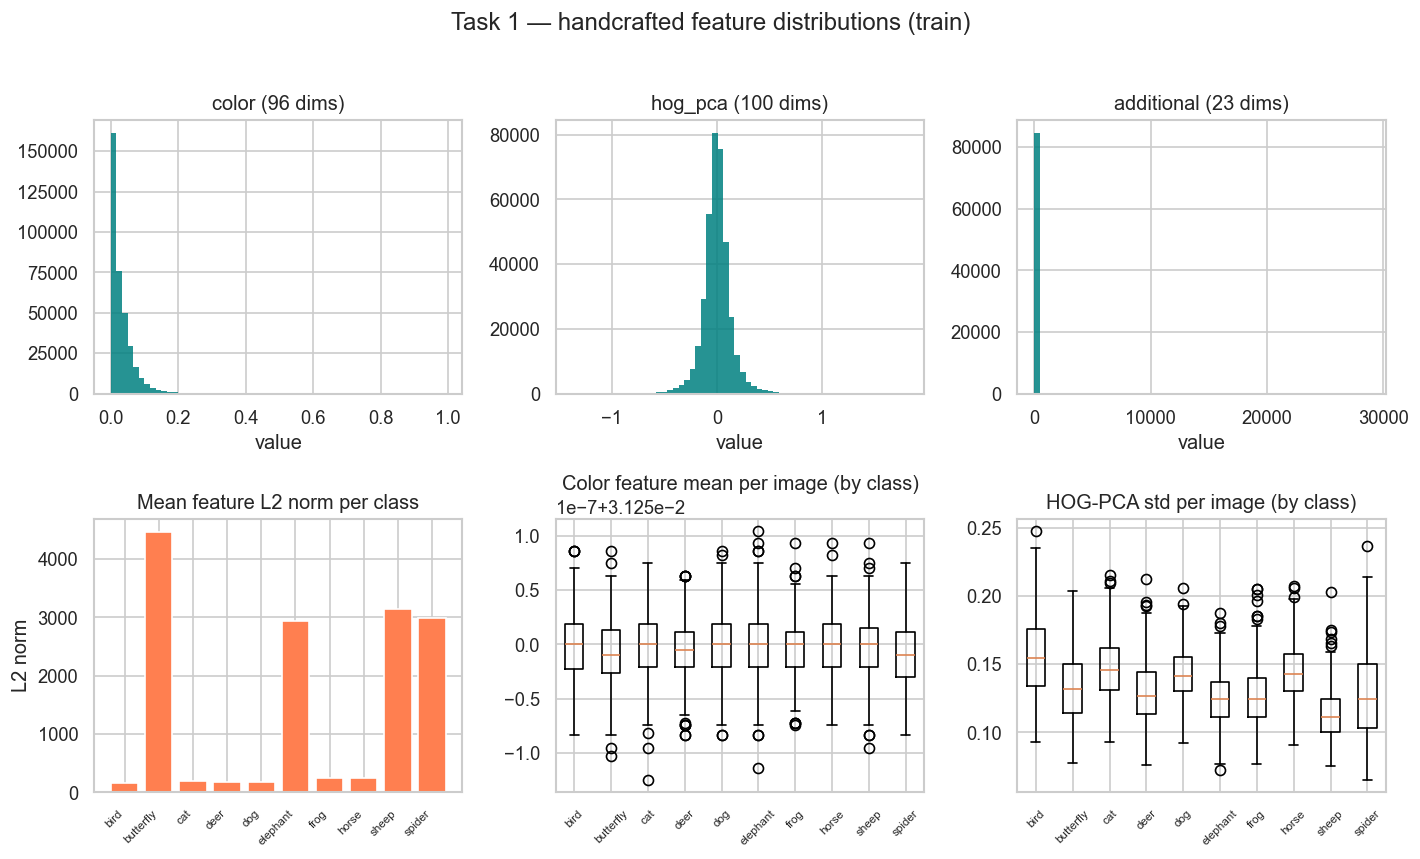

Saved /Users/skandaramanan/Documents/ML/MLAssignment2/outputs/figures/eda/task1_feature_distributions.png


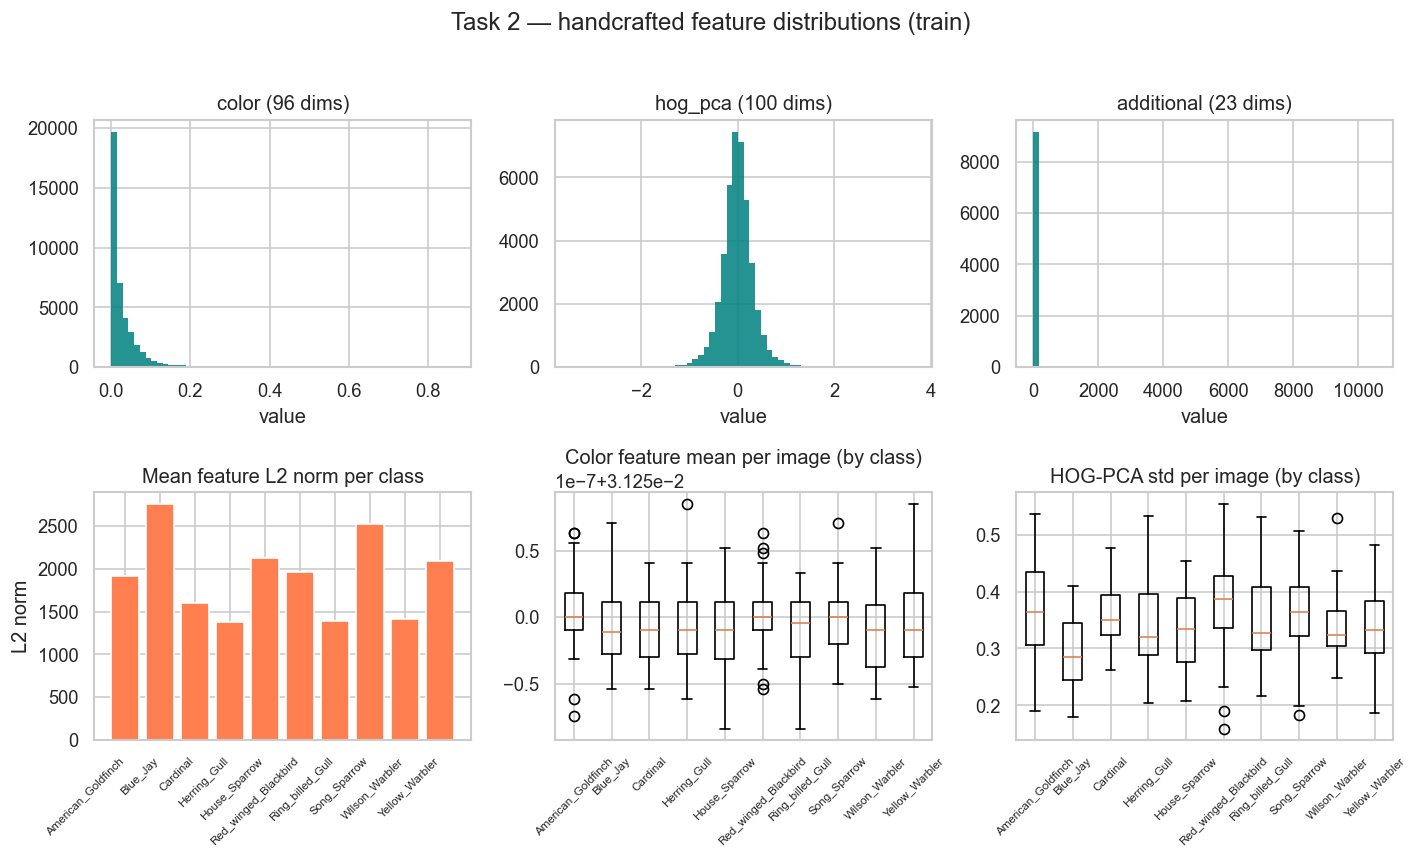

Saved /Users/skandaramanan/Documents/ML/MLAssignment2/outputs/figures/eda/task2_feature_distributions.png


In [14]:
def plot_feature_distributions(bundle, task_label: str, out_name: str):
    """Per-group histograms of all feature values + per-class mean L2 norm."""
    slices = feature_group_slices(bundle["feature_names"])
    X = bundle["X_handcrafted_train"]
    y = bundle["y_train"]
    class_names = bundle["class_mapping"].set_index("class_id").loc[sorted(np.unique(y)), "class_name"].tolist()

    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    fig.suptitle(f"{task_label} — handcrafted feature distributions (train)", y=1.02)

    for ax, (group, sl) in zip(axes[0], slices.items()):
        vals = X[:, sl].ravel()
        ax.hist(vals, bins=60, color="teal", alpha=0.85, edgecolor="none")
        ax.set_title(f"{group} ({sl.stop - sl.start} dims)")
        ax.set_xlabel("value")

    # Per-class mean vector norm (full 219-dim vector)
    norms = []
    for cid in sorted(np.unique(y)):
        mask = y == cid
        norms.append(np.linalg.norm(X[mask].mean(axis=0)))
    axes[1, 0].bar(range(len(norms)), norms, color="coral", edgecolor="white")
    axes[1, 0].set_xticks(range(len(norms)))
    axes[1, 0].set_xticklabels(class_names, rotation=45, ha="right", fontsize=7)
    axes[1, 0].set_title("Mean feature L2 norm per class")
    axes[1, 0].set_ylabel("L2 norm")

    # Colour channel means (first 32 bins as RGB-ish proxy: bins are flattened hist)
    color_block = X[:, slices["color"]]
    axes[1, 1].boxplot(
        [color_block[y == c].mean(axis=1) for c in sorted(np.unique(y))],
        tick_labels=class_names,
    )
    axes[1, 1].set_title("Color feature mean per image (by class)")
    axes[1, 1].tick_params(axis="x", rotation=45, labelsize=7)

    # HOG-PCA std per class
    hog_block = X[:, slices["hog_pca"]]
    axes[1, 2].boxplot(
        [hog_block[y == c].std(axis=1) for c in sorted(np.unique(y))],
        tick_labels=class_names,
    )
    axes[1, 2].set_title("HOG-PCA std per image (by class)")
    axes[1, 2].tick_params(axis="x", rotation=45, labelsize=7)

    fig.tight_layout()
    path = FIG_DIR / out_name
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved {path}")


plot_feature_distributions(task1, "Task 1", "task1_feature_distributions.png")
plot_feature_distributions(task2, "Task 2", "task2_feature_distributions.png")

## Sample images per class

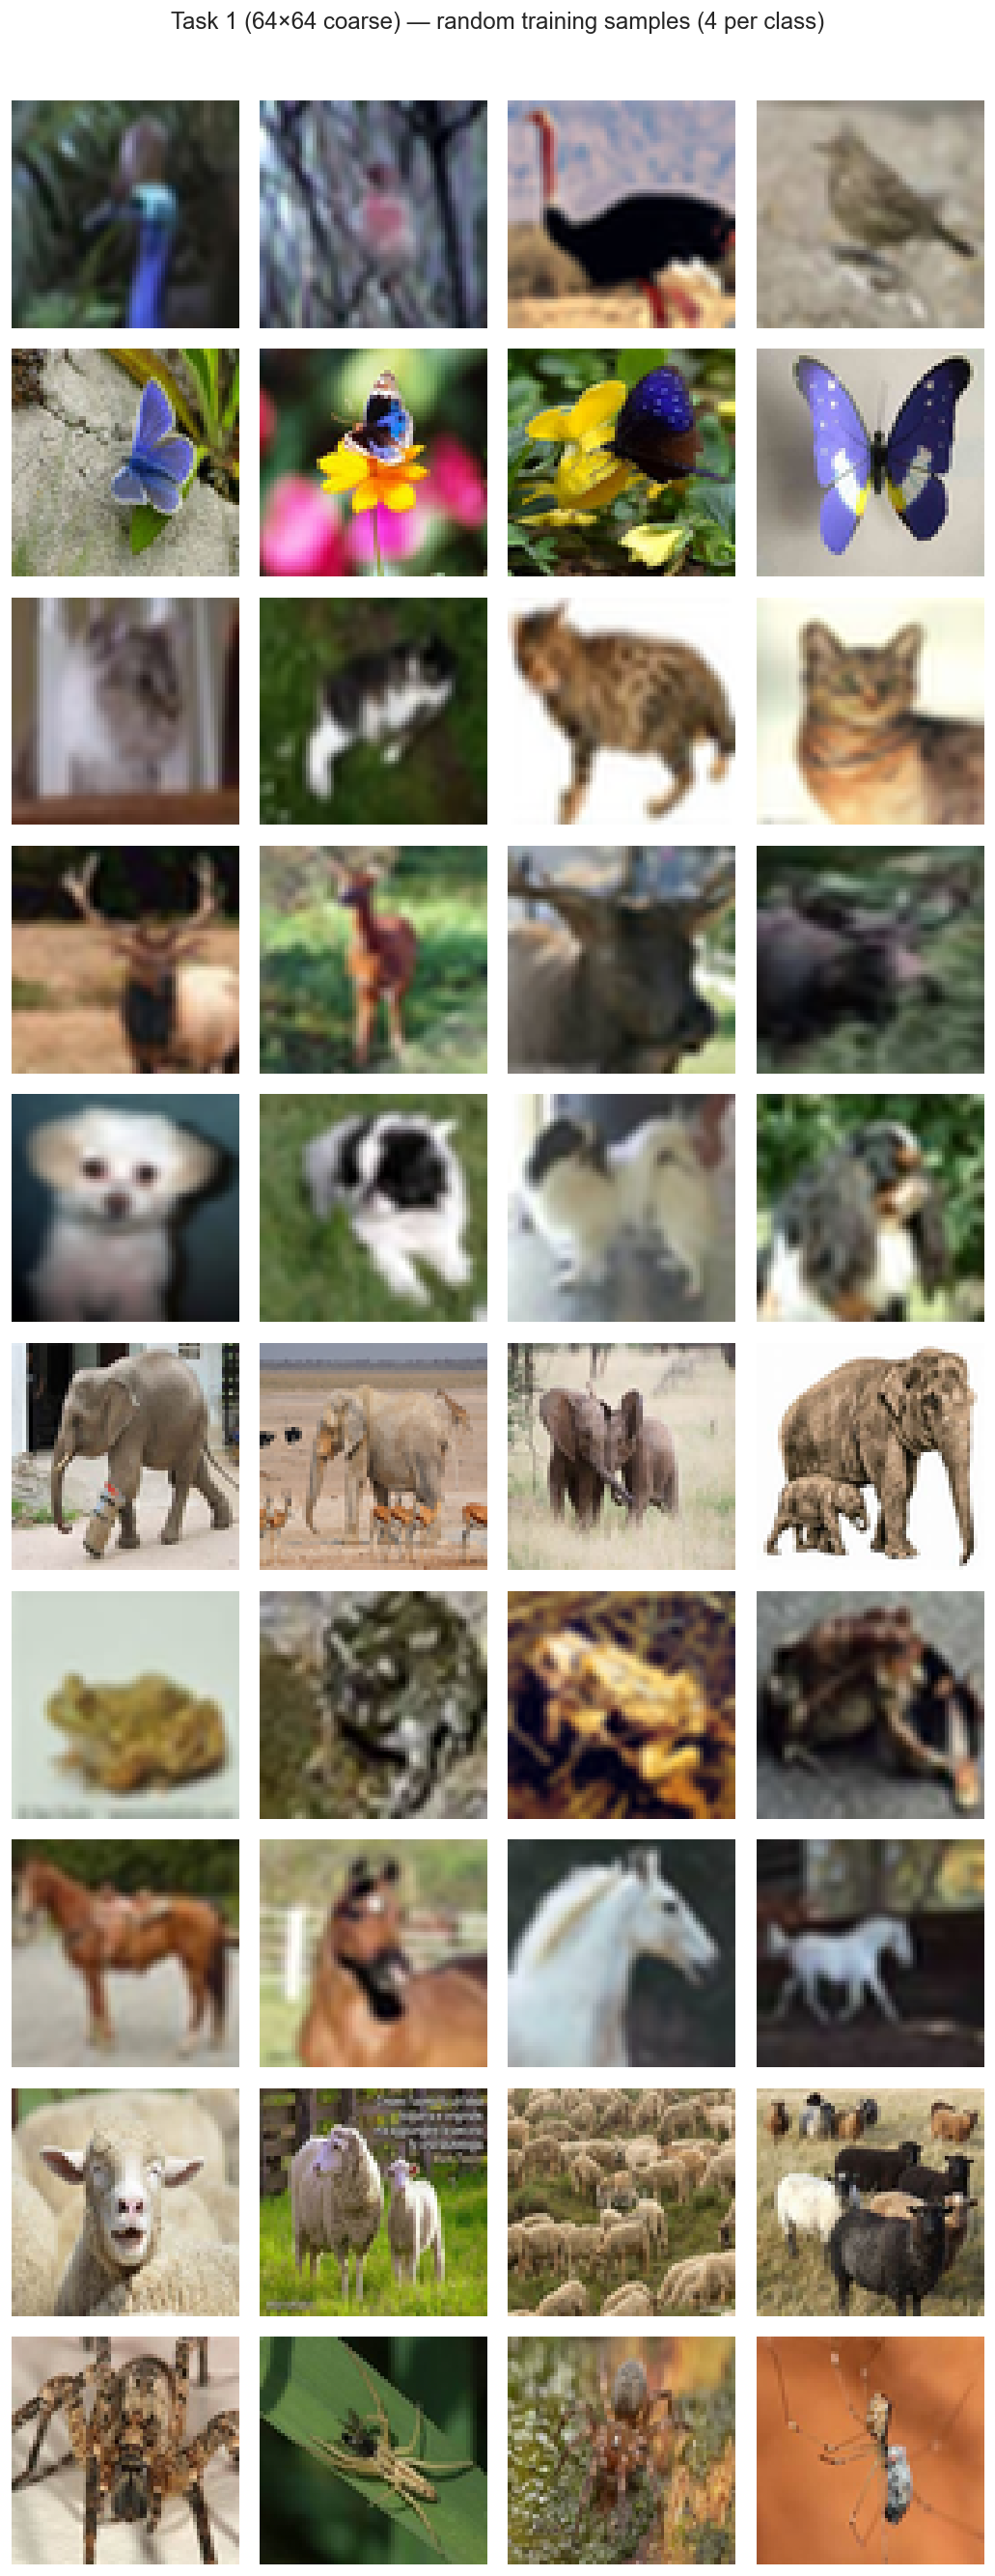

Saved /Users/skandaramanan/Documents/ML/MLAssignment2/outputs/figures/eda/task1_sample_images.png


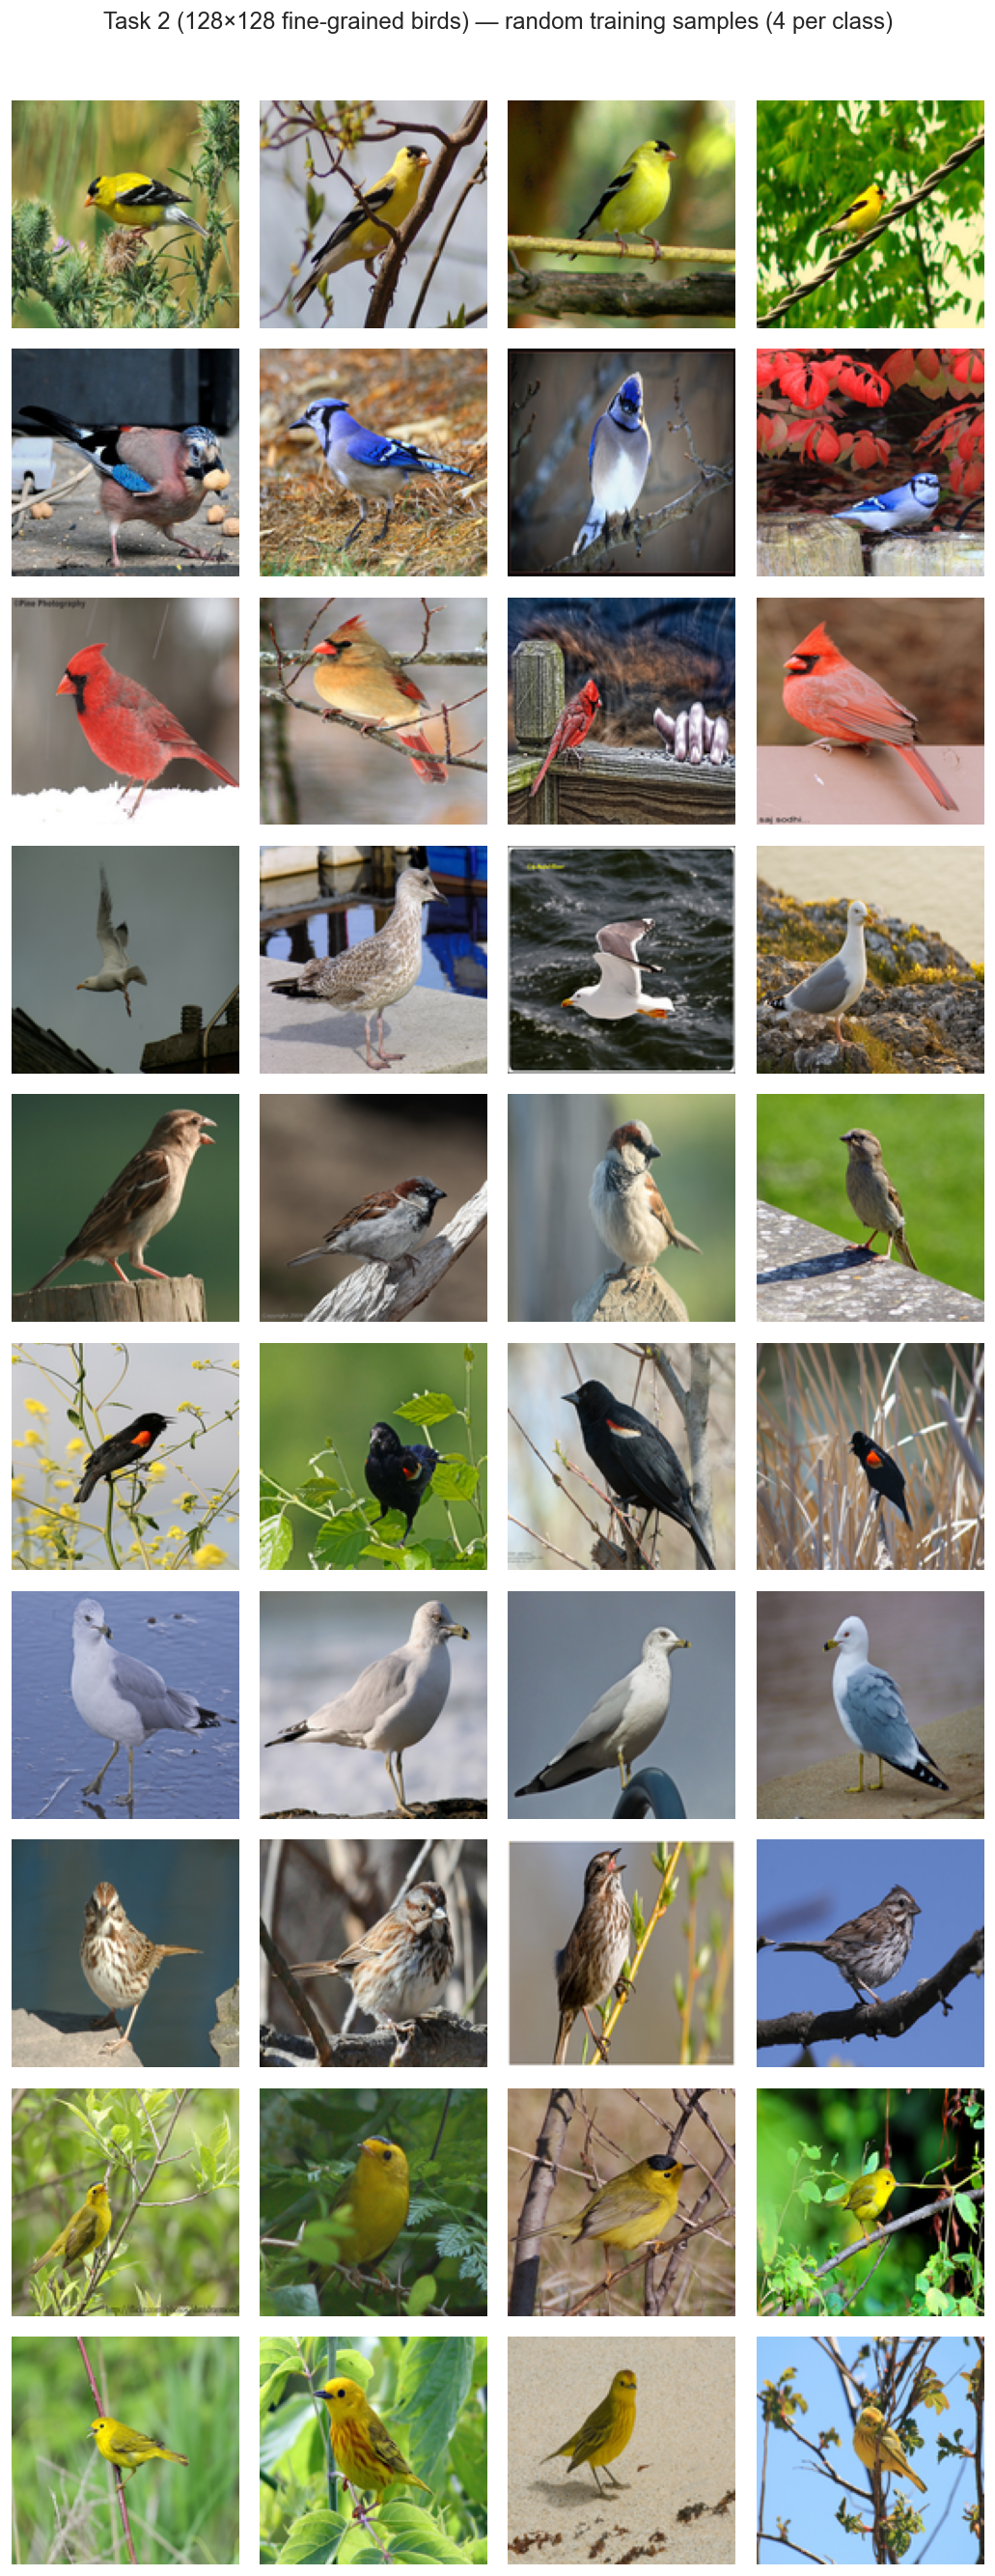

Saved /Users/skandaramanan/Documents/ML/MLAssignment2/outputs/figures/eda/task2_sample_images.png


In [15]:
def plot_sample_grid(bundle, task_label: str, out_name: str, n_per_class: int = 4):
    """Show `n_per_class` random training images per class."""
    meta = bundle["train_meta"].copy()
    class_ids = sorted(meta["class_id"].unique())
    n_classes = len(class_ids)

    fig, axes = plt.subplots(n_classes, n_per_class, figsize=(2.2 * n_per_class, 2.2 * n_classes))
    if n_classes == 1:
        axes = np.array([axes])
    fig.suptitle(f"{task_label} — random training samples ({n_per_class} per class)", y=1.01)

    for row, cid in enumerate(class_ids):
        subset = meta[meta["class_id"] == cid]
        pick = subset.sample(n=min(n_per_class, len(subset)), random_state=SEED + int(cid))
        images = list(load_images(pick, bundle["task_dir"]))
        cname = pick["class_name"].iloc[0]
        for col, (ax, im) in enumerate(zip(axes[row], images)):
            ax.imshow(im)
            ax.axis("off")
            if col == 0:
                ax.set_ylabel(cname, fontsize=8, rotation=0, ha="right", va="center", labelpad=42)
        for col in range(len(images), n_per_class):
            axes[row, col].axis("off")

    fig.tight_layout()
    path = FIG_DIR / out_name
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved {path}")


plot_sample_grid(task1, "Task 1 (64×64 coarse)", "task1_sample_images.png", n_per_class=4)
plot_sample_grid(task2, "Task 2 (128×128 fine-grained birds)", "task2_sample_images.png", n_per_class=4)

## Cross-task comparison & takeaways

In [16]:
comparison = pd.DataFrame([
    {
        "task": 1,
        "train_n": len(task1["y_train"]),
        "test_n": len(task1["test_ids"]),
        "n_classes": len(task1["class_mapping"]),
        "balance": "perfect (375/class)",
        "image_size": str(reports[0]["image_size"]),
        "feature_dim": task1["X_handcrafted_train"].shape[1],
    },
    {
        "task": 2,
        "train_n": len(task2["y_train"]),
        "test_n": len(task2["test_ids"]),
        "n_classes": len(task2["class_mapping"]),
        "balance": f"min {t2_counts['n_train'].min()}, max {t2_counts['n_train'].max()}",
        "image_size": str(reports[1]["image_size"]),
        "feature_dim": task2["X_handcrafted_train"].shape[1],
    },
])
display(comparison)

print(
    """
Key observations for modelling:
- Task 1: large, balanced 10-class coarse set (3,750 train / 1,250 test), 64×64 images.
- Task 2: small fine-grained bird set (417 train / 180 test), 128×128 images; Cardinal has 39 vs 42 elsewhere.
- Handcrafted features are aligned across all three CSVs (219 dims); no missing values.
- Test metadata is label-free (`image_id`, `image_path` only) — no test-label leakage.
- Additional descriptors dominate feature magnitude; `StandardScaler` in every pipeline is mandatory.
- Global colour/HOG descriptors may separate coarse categories but similar species (e.g. gulls, sparrows, warblers) will need CNN embeddings (notebook 01).
- Next: run 01_cnn_embeddings.ipynb to cache ResNet18 / EfficientNet-B0 features.
"""
)

,task,train_n,test_n,n_classes,balance,image_size,feature_dim
0,1,3750,1250,10,perfect (375/class),"(64, 64)",219
1,2,417,180,10,"min 39, max 42","(128, 128)",219



Key observations for modelling:
- Task 1: large, balanced 10-class coarse set (3,750 train / 1,250 test), 64×64 images.
- Task 2: small fine-grained bird set (417 train / 180 test), 128×128 images; Cardinal has 39 vs 42 elsewhere.
- Handcrafted features are aligned across all three CSVs (219 dims); no missing values.
- Test metadata is label-free (`image_id`, `image_path` only) — no test-label leakage.
- Additional descriptors dominate feature magnitude; `StandardScaler` in every pipeline is mandatory.
- Global colour/HOG descriptors may separate coarse categories but similar species (e.g. gulls, sparrows, warblers) will need CNN embeddings (notebook 01).
- Next: run 01_cnn_embeddings.ipynb to cache ResNet18 / EfficientNet-B0 features.

